## 1. Import libraries and simulation data

### 1.1 Libraries

In [1]:
import os
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

### 1.2 Load simulation files

In [2]:
# Keyword mapping: if any keyword appears in the filename, use the standard name
FILE_NAME_MAP = {
    "oxygen_concentration": ["oxygen", "o2", "concentration", "conc"],
    "pressure":             ["pressure", "pres", "press"],
    "velocity_field":       ["velocity", "vel", "speed", "flow"],
}

def standardize_name(file_stem: str) -> str:
    """Return the standard data type name for a given filename stem, or None if unrecognized."""
    lower = file_stem.lower()
    for standard_name, keywords in FILE_NAME_MAP.items():
        if any(kw in lower for kw in keywords):
            return standard_name
    return None  # Unrecognized file


def find_data_start(file_path: str, sep=",") -> int:
    """
    Skips metadata by finding the first line with the maximum field count.
    Works even when metadata lines outnumber data lines.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()
    
    field_counts = [len(line.split(sep)) for line in lines if line.strip()]
    max_count = max(field_counts)
    
    for i, line in enumerate(lines):
        if len(line.split(sep)) == max_count:
            return i  # This is your header row
    
    return 0


def load_csv_smart(file_path: str) -> pd.DataFrame:
    skip = find_data_start(file_path)
    if skip > 0:
        print(f"    ↳ Skipping {skip} metadata line(s)")
    return pd.read_csv(file_path, skiprows=skip)


# Dictionary to store all dataframes, keyed by (folder_name, file_stem)
dataframes = {}

# Base directory containing all simulation folders
base_dir = "simulation-data"

# Iterate through all subdirectories
for folder_name in sorted(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.isdir(folder_path):
        continue  # Skip any stray files
    
    for csv_file in sorted(os.listdir(folder_path)):
        if not csv_file.endswith(".csv"):
            continue

        file_stem = os.path.splitext(csv_file)[0]
        standard_name = standardize_name(file_stem)

        if standard_name is None:
            print(f"  ⚠ Skipped unrecognized file: {folder_name} / {csv_file}")
            continue

        key = (folder_name, standard_name)

        if key in dataframes:
            print(f"  ⚠ Duplicate detected for {key} — already loaded, skipping {csv_file}")
            continue

        file_path = os.path.join(folder_path, csv_file)
        dataframes[key] = load_csv_smart(file_path)
        print(f"Loaded: {folder_name} / {csv_file}  →  '{standard_name}'")
        

# Access example:
# dataframes[("020concentration", "species")]

Loaded: 020concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 020concentration / Pressure.csv  →  'pressure'
Loaded: 020concentration / Velocity_field.csv  →  'velocity_field'
Loaded: 021concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 021concentration / Pressure.csv  →  'pressure'
Loaded: 021concentration / Velocity.csv  →  'velocity_field'
Loaded: 022concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 022concentration / Pressure.csv  →  'pressure'
Loaded: 022concentration / Velocity.csv  →  'velocity_field'
    ↳ Skipping 8 metadata line(s)
Loaded: 023concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 023concentration / Pressure.csv  →  'pressure'
Loaded: 023concentration / Velocity.csv  →  'velocity_field'
    ↳ Skipping 8 metadata line(s)
Loaded: 024concentration / Oxygen_concentration.csv  →  'oxygen_concentration'
Loaded: 024concentration / Pressure.csv  →  'pressure'
Loaded: 024c

In [4]:
file_path = 'simulation-data/023concentration/Oxygen_concentration.csv'

with open(file_path, "r") as f:
    for i, line in enumerate(f):
        print(repr(line))  # repr() shows \t, \n etc. clearly
        if i >= 10:
            break

'% Model,TP423.mph\n'
'% Version,COMSOL 6.3.0.420\n'
'% Date,"Mar 22 2026, 16:13"\n'
'% Dimension,2\n'
'% Nodes,1\n'
'% Expressions,1060\n'
'% Description,"Molar concentration, c"\n'
'% Length unit,m\n'
'% x,y,c (mol/m^3) @ t=0,c (mol/m^3) @ t=0.001,c (mol/m^3) @ t=0.002,c (mol/m^3) @ t=0.003,c (mol/m^3) @ t=0.004,c (mol/m^3) @ t=0.005,c (mol/m^3) @ t=0.006,c (mol/m^3) @ t=0.007,c (mol/m^3) @ t=0.008,c (mol/m^3) @ t=0.009,c (mol/m^3) @ t=0.01,c (mol/m^3) @ t=0.011,c (mol/m^3) @ t=0.012,c (mol/m^3) @ t=0.013,c (mol/m^3) @ t=0.014,c (mol/m^3) @ t=0.015,c (mol/m^3) @ t=0.016,c (mol/m^3) @ t=0.017,c (mol/m^3) @ t=0.018,c (mol/m^3) @ t=0.019,c (mol/m^3) @ t=0.02,c (mol/m^3) @ t=0.021,c (mol/m^3) @ t=0.022,c (mol/m^3) @ t=0.023,c (mol/m^3) @ t=0.024,c (mol/m^3) @ t=0.025,c (mol/m^3) @ t=0.026,c (mol/m^3) @ t=0.027,c (mol/m^3) @ t=0.028,c (mol/m^3) @ t=0.029,c (mol/m^3) @ t=0.03,c (mol/m^3) @ t=0.031,c (mol/m^3) @ t=0.032,c (mol/m^3) @ t=0.033,c (mol/m^3) @ t=0.034,c (mol/m^3) @ t=0.035,c (mo

In [5]:
# List all loaded dataframes
for (folder, file), df in dataframes.items():
    print(f"{folder} / {file}: {df.shape}")

020concentration / oxygen_concentration: (1, 1102)
020concentration / pressure: (4203, 1102)
020concentration / velocity_field: (4203, 1102)
021concentration / oxygen_concentration: (1, 1062)
021concentration / pressure: (4203, 1062)
021concentration / velocity_field: (4203, 1062)
022concentration / oxygen_concentration: (1, 1062)
022concentration / pressure: (4203, 1062)
022concentration / velocity_field: (4203, 1062)
023concentration / oxygen_concentration: (1, 1062)
023concentration / pressure: (4203, 1062)
023concentration / velocity_field: (4203, 1062)
024concentration / oxygen_concentration: (1, 1062)
024concentration / pressure: (4203, 1062)
024concentration / velocity_field: (4203, 1062)
025concentration / oxygen_concentration: (1, 1102)
025concentration / pressure: (4203, 1102)
025concentration / velocity_field: (4203, 1102)
026concentration / oxygen_concentration: (1, 1062)
026concentration / pressure: (4203, 1062)
026concentration / velocity_field: (4203, 1062)
027concentrat

### 1.3 Access specific dataframe to check

In [6]:
# Access a specific one
sim_access = "021concentration"

dfoc = dataframes[(sim_access, "oxygen_concentration")]
dfpr = dataframes[(sim_access, "pressure")]
dfvf = dataframes[(sim_access, "velocity_field")]

dfpr

,x,y,p (Pa) @ t=0,p (Pa) @ t=0.001,p (Pa) @ t=0.002,p (Pa) @ t=0.003,p (Pa) @ t=0.004,p (Pa) @ t=0.005,p (Pa) @ t=0.006,p (Pa) @ t=0.007,...,p (Pa) @ t=3.55,p (Pa) @ t=3.6,p (Pa) @ t=3.65,p (Pa) @ t=3.7,p (Pa) @ t=3.75,p (Pa) @ t=3.8,p (Pa) @ t=3.85,p (Pa) @ t=3.9,p (Pa) @ t=3.95,p (Pa) @ t=4
0,0.011901,-0.002131,0.001811,0.001641,0.001962,0.002020,0.002106,0.002126,0.002135,0.002175,...,0.002451,0.002451,0.002451,0.002451,0.002451,0.002451,0.002451,0.002451,0.002451,0.002451
1,0.012000,-0.002072,0.001779,0.005133,0.005315,0.005265,0.005252,0.005222,0.005217,0.005213,...,0.005950,0.005950,0.005950,0.005950,0.005950,0.005950,0.005950,0.005950,0.005950,0.005950
2,0.011846,-0.002072,0.003125,0.001410,0.001680,0.001677,0.001773,0.001776,0.001778,0.001829,...,0.002029,0.002029,0.002029,0.002029,0.002029,0.002029,0.002029,0.002029,0.002029,0.002029
3,0.012000,-0.002140,0.000581,0.002116,0.002603,0.002749,0.002848,0.002890,0.002921,0.002939,...,0.003377,0.003377,0.003377,0.003377,0.003377,0.003377,0.003377,0.003377,0.003377,0.003377
4,0.011862,-0.003872,0.002827,0.001314,0.001461,0.001546,0.001586,0.001628,0.001607,0.001661,...,0.001806,0.001806,0.001806,0.001806,0.001806,0.001806,0.001806,0.001806,0.001806,0.001806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4198,-0.011382,0.000098,0.178686,0.046874,0.033331,0.032580,0.028254,0.029600,0.025441,0.029039,...,0.026369,0.026369,0.026369,0.026369,0.026369,0.026369,0.026369,0.026369,0.026369,0.026369
4199,-0.011525,0.000023,0.183148,0.047822,0.033795,0.033059,0.028602,0.029987,0.025748,0.029409,...,0.026712,0.026712,0.026712,0.026712,0.026713,0.026713,0.026713,0.026713,0.026713,0.026713
4200,-0.011533,0.000055,0.183082,0.047795,0.033774,0.033032,0.028574,0.029955,0.025715,0.029374,...,0.026662,0.026663,0.026663,0.026663,0.026663,0.026663,0.026663,0.026663,0.026663,0.026663
4201,-0.011682,-0.000008,0.188528,0.049759,0.035444,0.034608,0.030067,0.031466,0.027155,0.030884,...,0.028411,0.028411,0.028411,0.028411,0.028411,0.028411,0.028411,0.028411,0.028411,0.028411


### 1.4 Check dataframe sizes

In [7]:
from collections import defaultdict

# Group shapes by file type
shapes_by_type = defaultdict(dict)
for (folder, file_type), df in dataframes.items():
    shapes_by_type[file_type][folder] = df.shape

# Check consistency and report
all_ok = True
for file_type, folder_shapes in shapes_by_type.items():
    shapes = set(folder_shapes.values())
    
    if len(shapes) == 1:
        print(f"✓ {file_type}: all folders agree on shape {shapes.pop()}")
    else:
        all_ok = False
        print(f"✗ {file_type}: INCONSISTENT SHAPES")
        for folder, shape in folder_shapes.items():
            print(f"    {folder}: {shape}")

if all_ok:
    print("\nAll files are consistent.")
else:
    print("\nWarning: some files have mismatched dimensions — check the folders above.")

✗ oxygen_concentration: INCONSISTENT SHAPES
    020concentration: (1, 1102)
    021concentration: (1, 1062)
    022concentration: (1, 1062)
    023concentration: (1, 1062)
    024concentration: (1, 1062)
    025concentration: (1, 1102)
    026concentration: (1, 1062)
    027concentration: (1, 1062)
    028concentration: (1, 1062)
    029concentration: (1, 1062)
    030concentration: (1, 1102)
✗ pressure: INCONSISTENT SHAPES
    020concentration: (4203, 1102)
    021concentration: (4203, 1062)
    022concentration: (4203, 1062)
    023concentration: (4203, 1062)
    024concentration: (4203, 1062)
    025concentration: (4203, 1102)
    026concentration: (4203, 1062)
    027concentration: (4203, 1062)
    028concentration: (4203, 1062)
    029concentration: (4203, 1062)
    030concentration: (4203, 1102)
✗ velocity_field: INCONSISTENT SHAPES
    020concentration: (4203, 1102)
    021concentration: (4203, 1062)
    022concentration: (4203, 1062)
    023concentration: (4203, 1062)
    024co

### 1.5 Standardize dataframe size

In [8]:
def truncate_dataframes(dataframes: dict, expected_shape: dict) -> dict:
    """
    Truncates dataframes to the expected shape per file type.
    
    Args:
        dataframes: dict keyed by (folder_name, file_type)
        expected_shape: dict keyed by file_type, values are (rows, cols)
                        use None on either axis to skip truncation on that axis
    Returns:
        New dict with truncated dataframes.
    """
    truncated = {}
    all_ok = True

    for (folder, file_type), df in dataframes.items():
        target = expected_shape.get(file_type)

        if target is None:
            truncated[(folder, file_type)] = df
            continue

        target_rows, target_cols = target
        original_shape = df.shape

        if target_rows is not None:
            df = df.iloc[:target_rows, :]
        if target_cols is not None:
            df = df.iloc[:, :target_cols]

        if df.shape != original_shape:
            all_ok = False
            print(f"  ✂ Truncated {folder}/{file_type}: {original_shape} → {df.shape}")

        truncated[(folder, file_type)] = df

    if all_ok:
        print("✓ No truncation needed — all shapes already consistent.")
    else:
        print("\n✓ Truncation complete.")

    return truncated

In [9]:
EXPECTED_SHAPE = {
    "oxygen_concentration": (None, 1062),
    "pressure":             (4203, 1062),
    "velocity_field":       (4203, 1062),
}

dataframes_trunc = truncate_dataframes(dataframes, EXPECTED_SHAPE)

  ✂ Truncated 020concentration/oxygen_concentration: (1, 1102) → (1, 1062)
  ✂ Truncated 020concentration/pressure: (4203, 1102) → (4203, 1062)
  ✂ Truncated 020concentration/velocity_field: (4203, 1102) → (4203, 1062)
  ✂ Truncated 025concentration/oxygen_concentration: (1, 1102) → (1, 1062)
  ✂ Truncated 025concentration/pressure: (4203, 1102) → (4203, 1062)
  ✂ Truncated 025concentration/velocity_field: (4203, 1102) → (4203, 1062)
  ✂ Truncated 030concentration/oxygen_concentration: (1, 1102) → (1, 1062)
  ✂ Truncated 030concentration/pressure: (4203, 1102) → (4203, 1062)
  ✂ Truncated 030concentration/velocity_field: (4203, 1102) → (4203, 1062)

✓ Truncation complete.


In [10]:
# Access a specific one
sim_access = "022concentration"

dfoc = dataframes_trunc[(sim_access, "oxygen_concentration")]
dfpr = dataframes_trunc[(sim_access, "pressure")]
dfvf = dataframes_trunc[(sim_access, "velocity_field")]

dfoc

,x,y,c (mol/m^3) @ t=0,c (mol/m^3) @ t=0.001,c (mol/m^3) @ t=0.002,c (mol/m^3) @ t=0.003,c (mol/m^3) @ t=0.004,c (mol/m^3) @ t=0.005,c (mol/m^3) @ t=0.006,c (mol/m^3) @ t=0.007,...,c (mol/m^3) @ t=3.55,c (mol/m^3) @ t=3.6,c (mol/m^3) @ t=3.65,c (mol/m^3) @ t=3.7,c (mol/m^3) @ t=3.75,c (mol/m^3) @ t=3.8,c (mol/m^3) @ t=3.85,c (mol/m^3) @ t=3.9,c (mol/m^3) @ t=3.95,c (mol/m^3) @ t=4
0,0,-0.002,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.439994,0.439995,0.439996,0.439997,0.439998,0.439999,0.44,0.44,0.440001,0.440001


## 2. Process simulation data

### 2.1 Feature extraction v1

In [33]:
def extract_features(dataframes, folder_name):
    features = {}

    # --- Pressure & Velocity: shape (4203, ~1100) ---
    for name in ["Pressure", "Velocity_field"]:
        arr = dataframes[(folder_name, name)].values  # shape: (n_points, n_timesteps)

        features[f"{name}_mean"]             = arr.mean()
        features[f"{name}_std"]              = arr.std()
        features[f"{name}_max"]              = arr.max()
        features[f"{name}_min"]              = arr.min()
        features[f"{name}_temporal_trend"]   = np.polyfit(
            np.arange(arr.shape[1]), arr.mean(axis=0), 1
        )[0]
        features[f"{name}_spatial_std_mean"] = arr.std(axis=0).mean()

    # --- Oxygen concentration: shape (~1100, 2) ---
    df_o2    = dataframes[(folder_name, "Oxygen_concentration")]
    time_col = df_o2.iloc[:, 0].values
    conc_col = df_o2.iloc[:, 1].values

    features["O2_mean"]  = conc_col.mean()
    features["O2_std"]   = conc_col.std()
    features["O2_max"]   = conc_col.max()
    features["O2_min"]   = conc_col.min()
    features["O2_range"] = conc_col.max() - conc_col.min()
    features["O2_trend"] = np.polyfit(time_col, conc_col, 1)[0]

    return features

### 2.1 Feature extraction v2

In [11]:
def parse_timestamps(columns):
    """Extract float timestamps from column headers like 'p (Pa) @ t=0.003'."""
    timestamps = []
    for col in columns:
        match = re.search(r'@ t=([\d.eE+\-]+)', col)
        if match:
            timestamps.append(float(match.group(1)))
    return np.array(timestamps)


def get_data_columns(df):
    """Return only the timestamp columns (those containing '@ t=')."""
    return [col for col in df.columns if '@ t=' in col]


def interpolate_to_common_grid(df, common_times):
    """
    Interpolate all spatial points (rows) onto a common time grid.
    Returns a 2D numpy array of shape (n_points, len(common_times)).
    """
    time_cols = get_data_columns(df)
    timestamps = parse_timestamps(time_cols)
    data = df[time_cols].values  # shape: (n_points, n_timesteps)

    interpolated = np.zeros((data.shape[0], len(common_times)))
    for i, row in enumerate(data):
        interpolated[i] = np.interp(common_times, timestamps, row)

    return interpolated


def extract_features_pressure_velocity(df, common_times, field_name):
    """
    Extract features from a spatial field (pressure or velocity).
    Returns a flat dict of scalar features.
    """
    data = interpolate_to_common_grid(df, common_times)
    # data shape: (n_points, n_times)

    temporal_mean = data.mean(axis=1)       # mean over time, per point
    temporal_std  = data.std(axis=1)        # std over time, per point
    temporal_max  = data.max(axis=1)        # peak value per point
    peak_time_idx = data.argmax(axis=1)     # index of peak per point
    time_to_peak  = common_times[peak_time_idx]

    return {
        f"{field_name}_spatial_mean_of_temporal_mean": temporal_mean.mean(),
        f"{field_name}_spatial_mean_of_temporal_std":  temporal_std.mean(),
        f"{field_name}_spatial_std_of_temporal_mean":  temporal_mean.std(),
        f"{field_name}_spatial_mean_of_peak":          temporal_max.mean(),
        f"{field_name}_spatial_mean_of_time_to_peak":  time_to_peak.mean(),
    }


def extract_features_oxygen(df, common_times):
    """
    Extract features from oxygen concentration (single spatial point, time series).
    Returns a flat dict of scalar features.
    """
    time_cols = get_data_columns(df)
    timestamps = parse_timestamps(time_cols)
    values = df[time_cols].values.flatten()  # single row

    # Interpolate to common grid
    interp_values = np.interp(common_times, timestamps, values)

    initial_value = interp_values[0]
    final_value   = interp_values[-1]
    auc           = np.trapezoid(interp_values, common_times)

    # Time to drop to 50% of initial value (consumption proxy)
    half_initial  = 0.5 * initial_value
    crossings     = np.where(interp_values <= half_initial)[0]
    time_to_half  = common_times[crossings[0]] if len(crossings) > 0 else np.nan

    return {
        "oxygen_final_value":  final_value,
        "oxygen_mean":         interp_values.mean(),
        "oxygen_std":          interp_values.std(),
        "oxygen_auc":          auc,
        "oxygen_time_to_half": time_to_half,
    }


def extract_all_features(dataframes, n_common_times=200):
    """
    Main function. Iterates over all simulations and returns a
    DataFrame where each row is one simulation and each column is a feature.
    """
    # Build a common time grid from 0 to 4 seconds
    common_times = np.linspace(0, 4, n_common_times)

    all_features = {}

    # Get all unique folder names
    folders = sorted(set(folder for folder, _ in dataframes.keys()))

    for folder in folders:
        print(f"Processing {folder}...")
        features = {}

        for field, extractor in [
            ("pressure",      lambda df: extract_features_pressure_velocity(df, common_times, "pressure")),
            ("velocity_field", lambda df: extract_features_pressure_velocity(df, common_times, "velocity_field")),
            ("oxygen_concentration", lambda df: extract_features_oxygen(df, common_times)),
        ]:
            key = (folder, field)
            if key not in dataframes:
                print(f"  ⚠ Missing {field} for {folder}, skipping.")
                continue
            features.update(extractor(dataframes[key]))

        all_features[folder] = features

    return pd.DataFrame.from_dict(all_features, orient="index")


# Run it
feature_matrix = extract_all_features(dataframes)
print(feature_matrix.shape)
print(feature_matrix.head())

Processing 020concentration...
Processing 021concentration...
Processing 022concentration...
Processing 023concentration...
Processing 024concentration...
Processing 025concentration...
Processing 026concentration...
Processing 027concentration...
Processing 028concentration...
Processing 029concentration...
Processing 030concentration...
(11, 15)
                  pressure_spatial_mean_of_temporal_mean  \
020concentration                                0.014134   
021concentration                                0.025040   
022concentration                                0.022970   
023concentration                                0.020841   
024concentration                                0.018877   

                  pressure_spatial_mean_of_temporal_std  \
020concentration                               0.002035   
021concentration                               0.008135   
022concentration                               0.006311   
023concentration                               0.0045

### 2.2 Build feature matrix

In [55]:
folder_names = ["020concentration", "025concentration", "030concentration"]

records = []
for folder in folder_names:
    feats = extract_features(dataframes, folder)
    feats["simulation"] = folder   # keep track of which run
    records.append(feats)

df_features = pd.DataFrame(records).set_index("simulation")
print(df_features)

                  Pressure_mean  Pressure_std  Pressure_max  Pressure_min  \
simulation                                                                  
020concentration       0.013454      0.004957       0.03686        -0.014   
025concentration       0.015153      0.005971       0.03686        -0.014   
030concentration       0.010767      0.003708       0.03686        -0.014   

                  Pressure_temporal_trend  Pressure_spatial_std_mean  \
simulation                                                             
020concentration                 0.000009                   0.003012   
025concentration                 0.000012                   0.003406   
030concentration                 0.000006                   0.002394   

                  Velocity_field_mean  Velocity_field_std  Velocity_field_max  \
simulation                                                                      
020concentration             0.008150            0.010098            0.063901   
025concent

### 2.3 Visualize data

#### O2 Concentration over time, with regression line

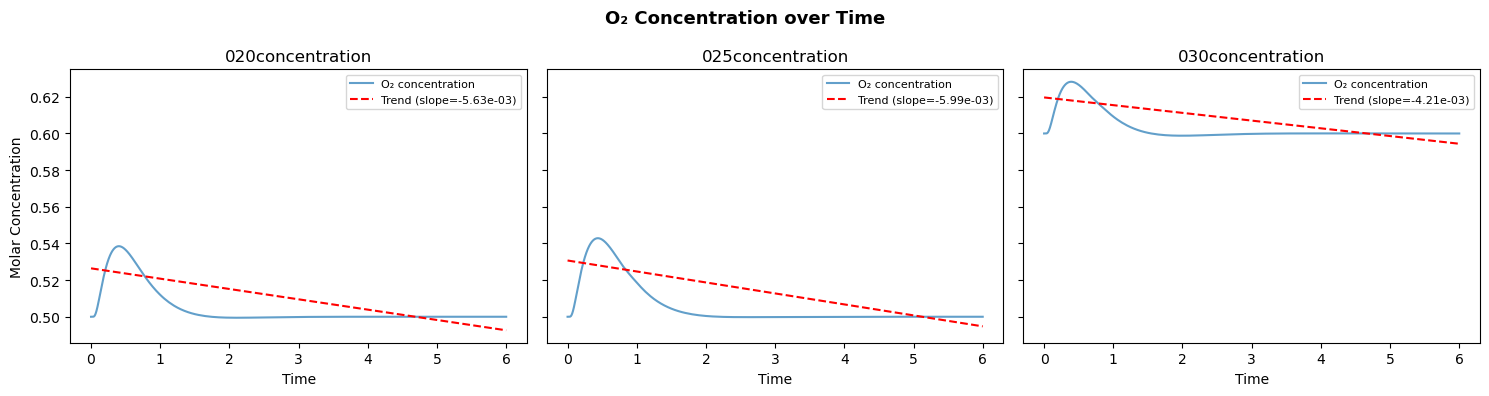

In [73]:
fig, axes = plt.subplots(1, len(folder_names), figsize=(5 * len(folder_names), 4), sharey=True)

for ax, folder_name in zip(axes, folder_names):
    df_o2    = dataframes[(folder_name, "Oxygen_concentration")]
    time_col = df_o2.iloc[:, 0].values
    conc_col = df_o2.iloc[:, 1].values

    # Regression line
    slope, intercept = np.polyfit(time_col, conc_col, 1)
    trend_line = slope * time_col + intercept

    ax.plot(time_col, conc_col, alpha=0.7, label="O₂ concentration")
    ax.plot(time_col, trend_line, "--", color="red",
            label=f"Trend (slope={slope:.2e})")

    ax.set_title(folder_name)
    ax.set_xlabel("Time")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Molar Concentration")
fig.suptitle("O₂ Concentration over Time", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("o2_trend.png", dpi=150)
plt.show()

#### All O2 curves on one plot

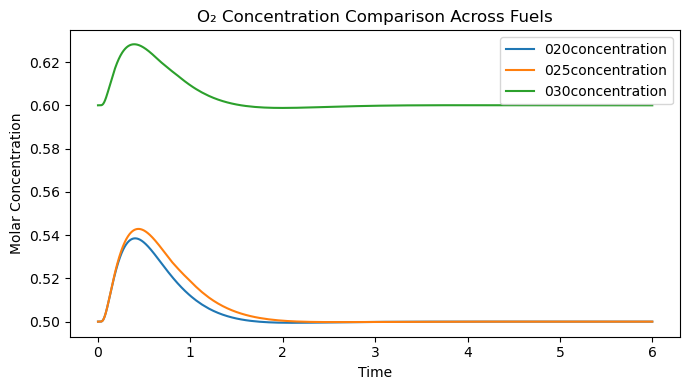

In [72]:
fig, ax = plt.subplots(figsize=(7, 4))

for folder_name in folder_names:
    df_o2    = dataframes[(folder_name, "Oxygen_concentration")]
    time_col = df_o2.iloc[:, 0].values
    conc_col = df_o2.iloc[:, 1].values
    ax.plot(time_col, conc_col, label=folder_name)

ax.set_xlabel("Time")
ax.set_ylabel("Molar Concentration")
ax.set_title("O₂ Concentration Comparison Across Fuels")
ax.legend()
plt.tight_layout()
# plt.savefig("o2_comparison.png", dpi=150)
plt.show()

#### Bar chart of extracted features per fuel

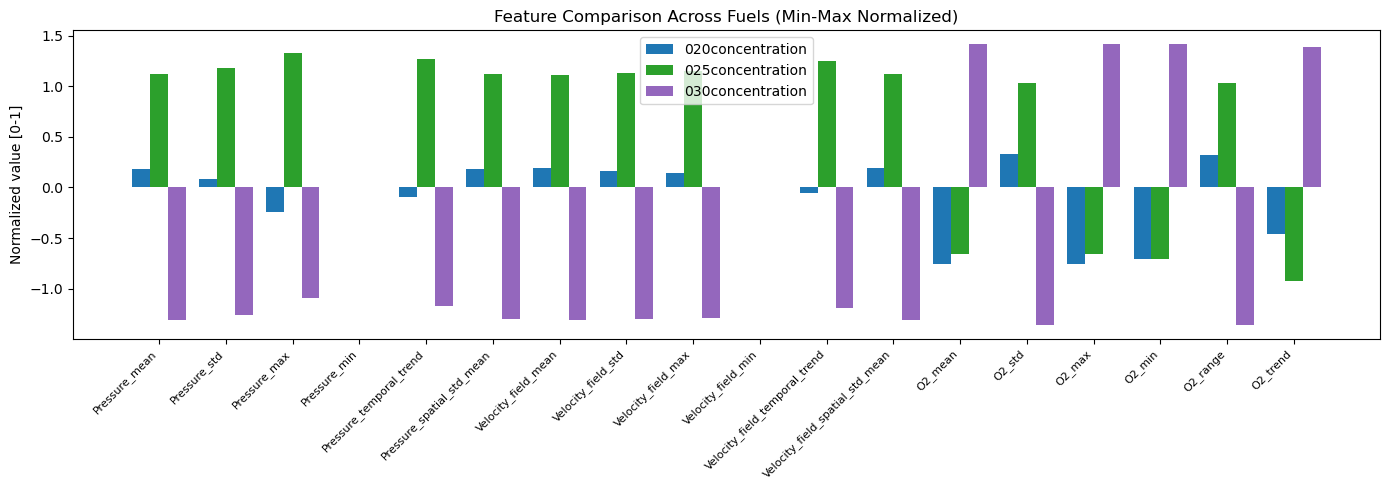

In [71]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Beacause we only have data from 3 fuel types, MinMaxScaler is not good for the analysis, 
# as it mapping the minimum observed value to 0 and the maximum to 1. With only 3 simulations, 
# every feature column has exactly 3 values, so one simulation will always land at 0, another at 1, 
# and only the middle one gets an intermediate value. It's mathematically correct but visually 
# useless for a heatmap.

scaler_viz = StandardScaler()
df_normalized = pd.DataFrame(
    scaler_viz.fit_transform(df_features),
    index=df_features.index,
    columns=df_features.columns
)

fig, ax = plt.subplots(figsize=(14, 5))

x      = np.arange(len(df_normalized.columns))
width  = 0.8 / len(folder_names)
colors = plt.cm.tab10(np.linspace(0, 0.4, len(folder_names)))

for i, (folder_name, row) in enumerate(df_normalized.iterrows()):
    ax.bar(x + i * width, row.values, width, label=folder_name, color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(df_normalized.columns, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Normalized value [0-1]")
ax.set_title("Feature Comparison Across Fuels (Min-Max Normalized)")
ax.legend()
plt.tight_layout()
# plt.savefig("feature_comparison.png", dpi=150)
plt.show()

#### Heatmap of the feature matrix

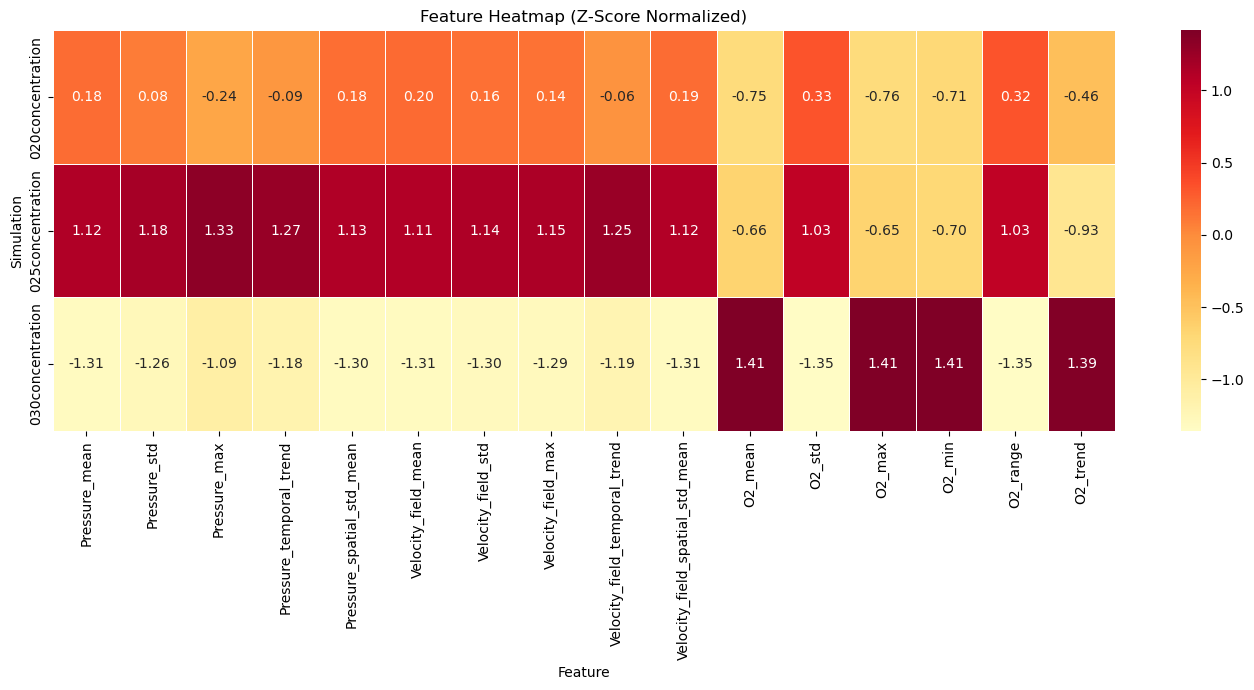

In [70]:
import seaborn as sns

# Drop the cluster column and any zero-variance columns before normalizing
df_for_viz = df_features.drop(columns=["cluster"], errors="ignore")
df_for_viz = df_for_viz.loc[:, df_for_viz.std() > 0]  # remove constant columns

scaler_viz = StandardScaler()
df_normalized = pd.DataFrame(
    scaler_viz.fit_transform(df_for_viz),
    index=df_for_viz.index,
    columns=df_for_viz.columns
)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    df_normalized,
    annot=True, fmt=".2f",
    cmap="YlOrRd",   # better for z-scores: blue=below avg, red=above avg
    center=0,          # important: anchors the colormap at 0
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Heatmap (Z-Score Normalized)")
ax.set_xlabel("Feature")
ax.set_ylabel("Simulation")
plt.tight_layout()
# plt.savefig("feature_heatmap.png", dpi=150)
plt.show()

In [53]:
print(df_normalized.shape)
print(df_normalized)

(3, 19)
                  Pressure_mean  Pressure_std  Pressure_max  Pressure_min  \
simulation                                                                  
020concentration       0.182410      0.084455     -0.239244           0.0   
025concentration       1.123310      1.180331      1.326714           0.0   
030concentration      -1.305719     -1.264787     -1.087471           0.0   

                  Pressure_temporal_trend  Pressure_spatial_std_mean  \
simulation                                                             
020concentration                -0.092546                   0.178734   
025concentration                 1.268392                   1.125557   
030concentration                -1.175847                  -1.304291   

                  Velocity_field_mean  Velocity_field_std  Velocity_field_max  \
simulation                                                                      
020concentration             0.196370            0.162553            0.141818   
02

## 3. Machine Learning

### 3.1 Import libraries

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### 3.2 Normalize data

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

### 3.2 K-Means

In [38]:
# With only 3 simulations, use k=3 (one cluster per fuel is the hypothesis)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df_features["cluster"] = labels
print(df_features["cluster"])

simulation
020concentration    2
025concentration    0
030concentration    1
Name: cluster, dtype: int32


c:\Users\icaro\anaconda3\envs\insights-combustion\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### 3.3 Visualize with PCA

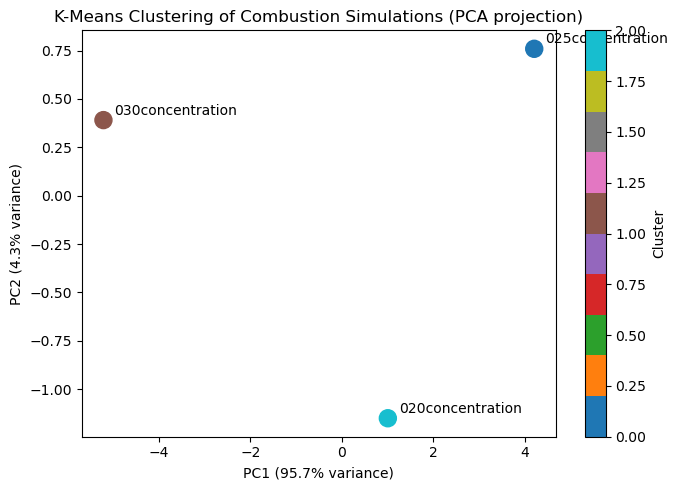

In [39]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=150, zorder=3)
for i, name in enumerate(df_features.index):
    plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), textcoords="offset points", xytext=(8, 4))
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("K-Means Clustering of Combustion Simulations (PCA projection)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()

### Important Caveats to Keep in Mind:
Only 3 samples is very limiting. K-Means with k=3 on 3 points will always assign one point per cluster — it's trivially "correct" but tells you nothing statistically meaningful. The real value will come when you have more simulation runs (different fuel types, equivalence ratios, temperatures, etc.).

The features you extract matter enormously. The slope of O2 concentration over time (O2_trend) is likely one of your most physically meaningful features — it directly represents the oxygen consumption rate, which differs between fuels. Think about what combustion physics tells you to look for.

Scaling is non-negotiable. Pressure values will be orders of magnitude larger than molar concentrations, so without StandardScaler, K-Means will be dominated by whichever variable has the largest absolute values.

Once you have more simulation runs, you can also use the elbow method or silhouette score to find the optimal k rather than hardcoding it. Would you like me to add that, or dig deeper into any particular part of this pipeline?